# Car Price Prediction — Handling Categorical Values
### Task 3 | OIBSIP Data Science Internship

This notebook covers:<br>
[x] Download a suitable dataset (see Self-Sourcing Guideline below) <br>
[x] Data cleaning: handle null values, remove duplicates, address inconsistent categorical values (e.g., "Petrol" vs. "petrol")<br>
[x] Feature engineering: calculate car age from the year column; extract brand from the car name column<br>
[x] EDA distribution of selling prices, price vs. fuel type box plots, price vs. car age scatter plot<br>
[x] Encode categorical variables (One-Hot Encoding or Label Encoding)<br>
[x] Feature correlation heatmap<br>
[x] Train-test split<br>
[x] Train at least 2 regression models (e.g., Linear Regression, Random Forest Regressor, Gradient Boosting)<br>
[x] Evaluate models using: MAE, RMSE, and R² score<br>
[x] Feature importance chart for your best-performing model<br>
[x] All steps in a clean, commented Jupyter Notebook<br>

# Car Price Prediction: End-to-End Machine Learning Project

**Objective:** To predict the resale value of used cars based on historical market data (mileage, age, brand, fuel type, etc.) to help dealerships and buyers estimate fair market prices.

**Key Results:**
* Engineered a robust dataset from 4,340 raw listings, extracting features like `car_age` and capping extreme outliers.
* Evaluated Linear Regression, Random Forest, and XGBoost.
* **Winning Model:** XGBoost achieved the best performance with an **R² score of 0.77**, successfully capturing the complex, non-linear depreciation of vehicles.
* **Core Insight:** Vehicle age, transmission type, and the Toyota brand premium are the highest weighted factors determining a car's final selling price.

# Opening CSV

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np
from datetime import datetime

df = pd.read_csv('CAR DETAILS FROM CAR DEKHO.csv')
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (4340, 8)


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


# Cleaning

In [2]:
print(df.isnull().sum())
print(f'\n{df.duplicated().sum()} is Duplicated rows')

name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
dtype: int64

763 is Duplicated rows


Dropped Down Duplicates

In [3]:
df = df.drop_duplicates()
df.shape

(3577, 8)

In [4]:
df.info() # name, fuel, seller_type, transmission, owner 

<class 'pandas.core.frame.DataFrame'>
Index: 3577 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           3577 non-null   object
 1   year           3577 non-null   int64 
 2   selling_price  3577 non-null   int64 
 3   km_driven      3577 non-null   int64 
 4   fuel           3577 non-null   object
 5   seller_type    3577 non-null   object
 6   transmission   3577 non-null   object
 7   owner          3577 non-null   object
dtypes: int64(3), object(5)
memory usage: 251.5+ KB


In [5]:
df.columns

Index(['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type',
       'transmission', 'owner'],
      dtype='object')

In [6]:
print(df['fuel'].unique())
print(df['fuel'].str.upper())

['Petrol' 'Diesel' 'CNG' 'LPG' 'Electric']
0       PETROL
1       PETROL
2       DIESEL
3       PETROL
4       DIESEL
         ...  
4335    DIESEL
4336    DIESEL
4337    PETROL
4338    DIESEL
4339    PETROL
Name: fuel, Length: 3577, dtype: object


In [7]:
df.describe()

,year,selling_price,km_driven
count,3577.000000,3.577000e+03,3577.000000
mean,2012.962538,4.739125e+05,69250.545709
std,4.251759,5.093018e+05,47579.940016
min,1992.000000,2.000000e+04,1.000000
25%,2010.000000,2.000000e+05,36000.000000
50%,2013.000000,3.500000e+05,60000.000000
75%,2016.000000,6.000000e+05,90000.000000
max,2020.000000,8.900000e+06,806599.000000


In [8]:
print(f'{df['selling_price'].quantile(0.75)} - 75% Car Price' )
print(f'{df['selling_price'].max()} - Max Car Price' )

print(f'{df['km_driven'].quantile(0.75)} - 75% KM Driven' )
print(f'{df['km_driven'].max()}- Max KM Driven')

600000.0 - 75% Car Price
8900000 - Max Car Price
90000.0 - 75% KM Driven
806599- Max KM Driven


Detected as Outliers

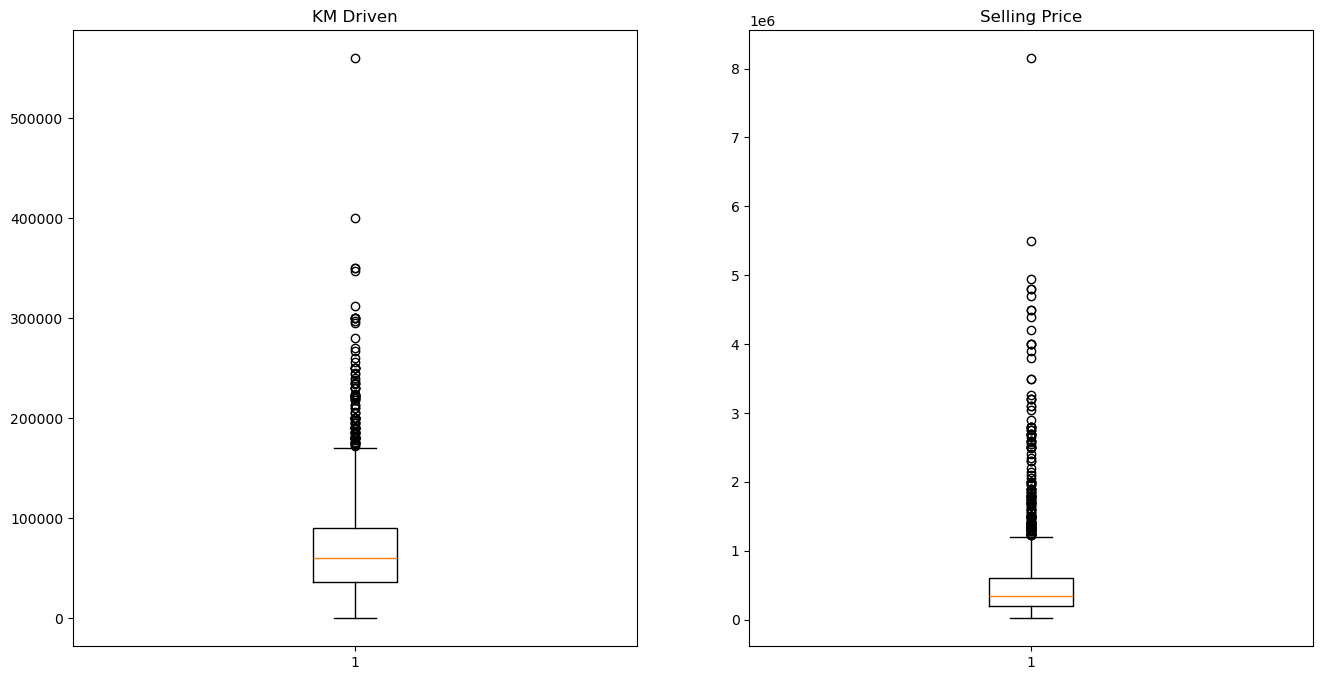

In [60]:
# Outlier confirming
plt.figure(figsize=(16,8))
plt.subplot(1, 2, 1)
plt.boxplot(df["km_driven"])
plt.title("KM Driven")

plt.subplot(1, 2, 2)
plt.boxplot(df["selling_price"])
plt.title("Selling Price")
plt.savefig("Outliers_BoxPlot.png")
plt.show()

In [10]:
out1 = df['selling_price'].idxmax()
df.loc[[out1]]

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
3872,Audi RS7 2015-2019 Sportback Performance,2016,8900000,13000,Petrol,Dealer,Automatic,First Owner


In [11]:
for i, name in enumerate(df['name']):
    if name == 'Audi RS7 2015-2019 Sportback Performance':
        print(df.iloc[[i]])

                                          name  year  selling_price  \
3872  Audi RS7 2015-2019 Sportback Performance  2016        8900000   

      km_driven    fuel seller_type transmission        owner  
3872      13000  Petrol      Dealer    Automatic  First Owner  


Putting mean Value to control outliers of selling price

In [12]:
df.loc[3872, 'selling_price'] = df['selling_price'].mean()
df.loc[3872]

C:\Users\anuru\AppData\Local\Temp\ipykernel_21508\3666521070.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '473912.54207436397' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[3872, 'selling_price'] = df['selling_price'].mean()


name             Audi RS7 2015-2019 Sportback Performance
year                                                 2016
selling_price                               473912.542074
km_driven                                           13000
fuel                                               Petrol
seller_type                                        Dealer
transmission                                    Automatic
owner                                         First Owner
Name: 3872, dtype: object

In [13]:
df['selling_price'].max()

8150000.0

In [14]:
out2 = df['km_driven'].idxmax()
df.loc[[out2]]

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
1243,Maruti Swift VXI BSIII,2009,250000.0,806599,Petrol,Dealer,Manual,First Owner


In [15]:
for i, name in enumerate(df['name']):
    if name == 'Maruti Swift VXI BSIII':
        print(df.iloc[[i]])

mean = (67580+70000+95149)/3
x = round(mean,2)
df.loc[1243, 'km_driven'] = x

                       name  year  selling_price  km_driven    fuel  \
384  Maruti Swift VXI BSIII  2011       250000.0      70000  Petrol   

    seller_type transmission         owner  
384  Individual       Manual  Second Owner  
                        name  year  selling_price  km_driven    fuel  \
1243  Maruti Swift VXI BSIII  2009       250000.0     806599  Petrol   

     seller_type transmission        owner  
1243      Dealer       Manual  First Owner  
                        name  year  selling_price  km_driven    fuel  \
2409  Maruti Swift VXI BSIII  2006       160000.0      95149  Petrol   

     seller_type transmission         owner  
2409      Dealer       Manual  Second Owner  
                        name  year  selling_price  km_driven    fuel  \
4082  Maruti Swift VXI BSIII  2009       220000.0      67580  Petrol   

     seller_type transmission         owner  
4082  Individual       Manual  Second Owner  


C:\Users\anuru\AppData\Local\Temp\ipykernel_21508\1918468257.py:7: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '77576.33' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[1243, 'km_driven'] = x


In [16]:
# Capping teq with the Outliers 
data = df.copy()
def cap_outliers(data, col):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    print(f"{col} → clipping [{lower:.0f}, {upper:.0f}]")
    data[col] = data[col].clip(lower, upper)
    return data

data = cap_outliers(data, 'selling_price')
data = cap_outliers(data, 'km_driven')

selling_price → clipping [-400000, 1200000]
km_driven → clipping [-45000, 171000]


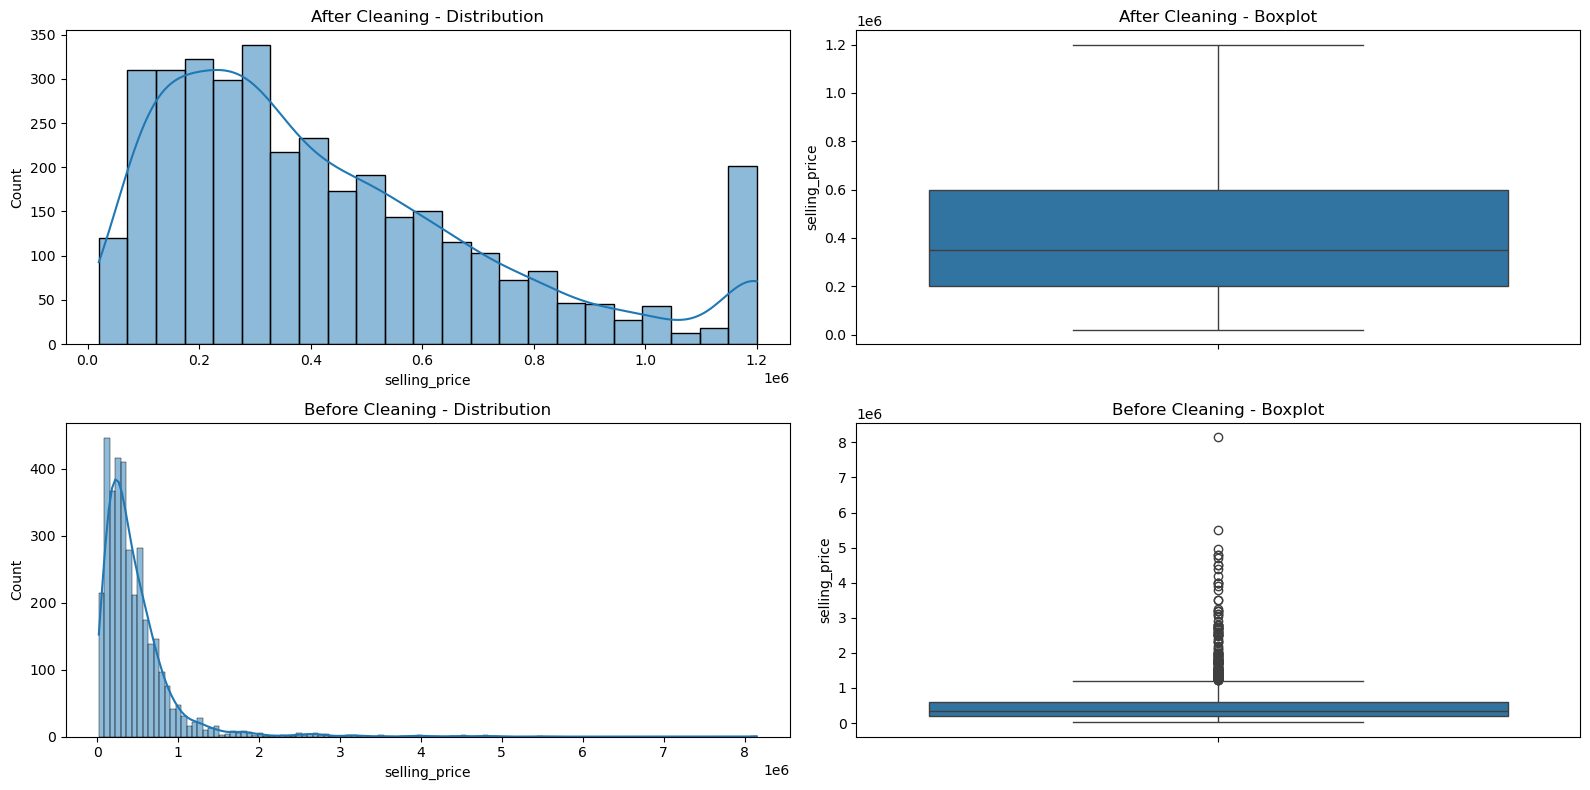

In [59]:
# Difference after and before plotting
fig, axes = plt.subplots(2, 2, figsize=(16, 8))
# After cleaning - Distribution
sns.histplot(data, x='selling_price', kde=True, ax=axes[0, 0])
axes[0, 0].set_title('After Cleaning - Distribution')

# After cleaning - Boxplot
sns.boxplot(data['selling_price'], ax=axes[0, 1])
axes[0, 1].set_title('After Cleaning - Boxplot')

# Before cleaning - Distribution
sns.histplot(df, x='selling_price', kde=True, ax=axes[1, 0])
axes[1, 0].set_title('Before Cleaning - Distribution')

# Before cleaning - Boxplot
sns.boxplot(df['selling_price'], ax=axes[1, 1])
axes[1, 1].set_title('Before Cleaning - Boxplot')

plt.tight_layout()
plt.savefig("Distribution_selling_price.png")
plt.show()

After the observation it is clearly shows here that how After Capping the Outliers are gone, so the Distribution got some changes in pdf(Probability Density Function) on **selling_price** column.

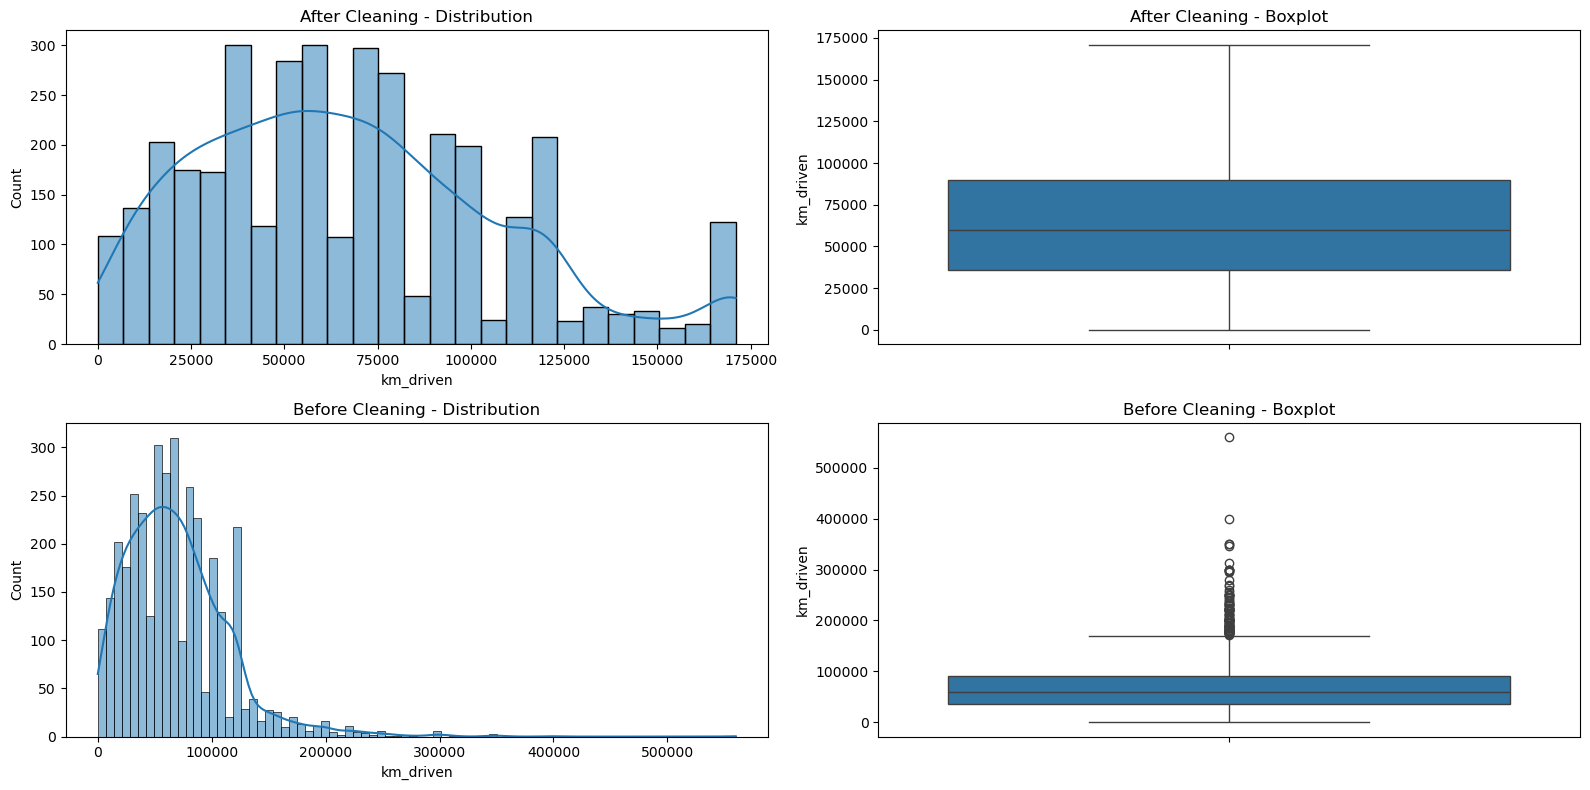

In [58]:
# Difference after and before plotting
fig, axes = plt.subplots(2, 2, figsize=(16, 8))
# After cleaning - Distribution
sns.histplot(data, x='km_driven', kde=True, ax=axes[0, 0])
axes[0, 0].set_title('After Cleaning - Distribution')

# After cleaning - Boxplot
sns.boxplot(data['km_driven'], ax=axes[0, 1])
axes[0, 1].set_title('After Cleaning - Boxplot')

# Before cleaning - Distribution
sns.histplot(df, x='km_driven', kde=True, ax=axes[1, 0])
axes[1, 0].set_title('Before Cleaning - Distribution')

# Before cleaning - Boxplot
sns.boxplot(df['km_driven'], ax=axes[1, 1])
axes[1, 1].set_title('Before Cleaning - Boxplot')

plt.tight_layout()
plt.savefig("Distribution_km_driven.png")
plt.show()

Observation: Price & Mileage Outlier Treatment

The initial selling_price and km_driven distributions were heavily right-skewed, driven by a few ultra-luxury vehicles and extreme-high-mileage cars.
By applying IQR capping, we effectively bound the maximum selling price to ₹1.2M and max mileage to ~171k km.
Insight: This transformation prevents our machine learning models from being artificially skewed by rare edge cases, ensuring more accurate price predictions for the average consumer market.

In [19]:
col = data.columns
for i in col:
    print(f"\n{i}:")
    print(data[i].nunique())



name:
1491

year:
27

selling_price:
364

km_driven:
720

fuel:
5

seller_type:
3

transmission:
2

owner:
5


In [20]:
data['fuel'].value_counts()

fuel
Diesel      1800
Petrol      1717
CNG           37
LPG           22
Electric       1
Name: count, dtype: int64

In [21]:
print(data['fuel'].unique())
print(data['seller_type'].unique())
print(data['transmission'].unique())
print(data['owner'].unique())

['Petrol' 'Diesel' 'CNG' 'LPG' 'Electric']
['Individual' 'Dealer' 'Trustmark Dealer']
['Manual' 'Automatic']
['First Owner' 'Second Owner' 'Fourth & Above Owner' 'Third Owner'
 'Test Drive Car']


In [22]:
# Car Age Manupulation
current_year = datetime.now().year          
df['car_age'] = current_year - df['year']

# EDA

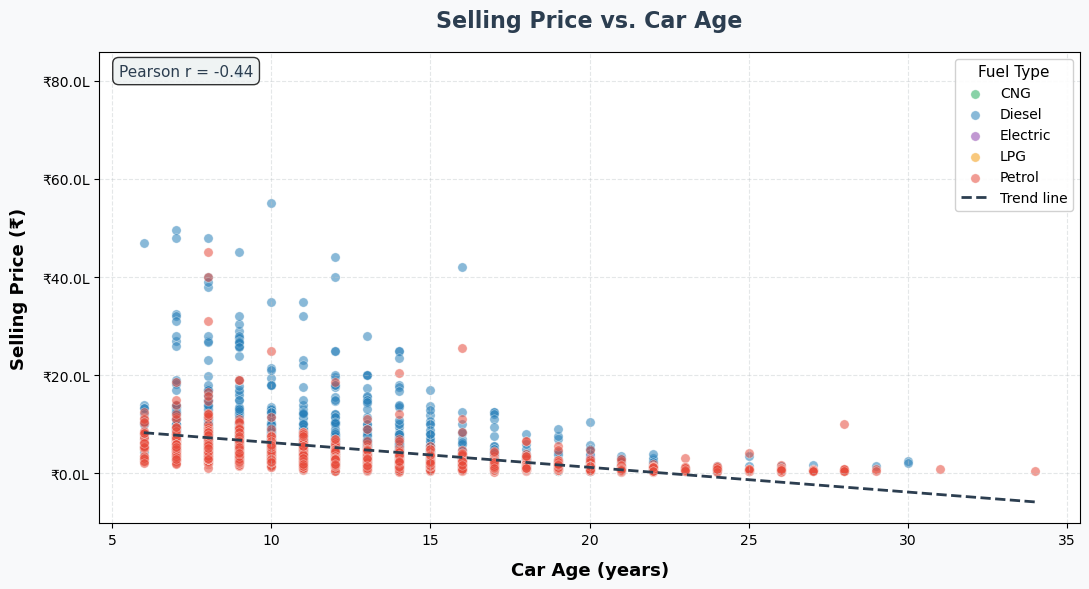


Correlation between Car Age and Selling Price: -0.4381
(Negative value means older cars → lower price, as expected)


In [57]:
# Scatter Plot: Selling Price vs. Car Age

fuel_colors = {
    'Petrol': '#E74C3C',
    'Diesel': '#2980B9',
    'CNG': '#27AE60',
    'LPG': '#F39C12',
    'Electric': '#8E44AD'
}

fig, ax = plt.subplots(figsize=(11, 6))
fig.patch.set_facecolor('#F8F9FA')
ax.set_facecolor('#FFFFFF')

# Plot each fuel type as a separate group so the legend works
for fuel, grp in df.groupby('fuel'):
    ax.scatter(
        grp['car_age'],
        grp['selling_price'],
        label=fuel,
        color=fuel_colors.get(fuel, '#95A5A6'),
        alpha=0.55,
        edgecolors='white',
        linewidths=0.4,
        s=45
    )

# ---- Trend line (linear regression) ----
z = np.polyfit(
    df['car_age'],
    df['selling_price'],
    1
)

p = np.poly1d(z)

x_line = np.linspace(
    df['car_age'].min(),
    df['car_age'].max(),
    200
)

ax.plot(
    x_line,
    p(x_line),
    color='#2C3E50',
    linewidth=2,
    linestyle='--',
    label='Trend line',
    zorder=5
)

# ---- Axes labels & title ----
ax.set_xlabel(
    'Car Age (years)',
    fontsize=13,
    fontweight='bold',
    labelpad=10
)

ax.set_ylabel(
    'Selling Price (₹)',
    fontsize=13,
    fontweight='bold',
    labelpad=10
)

ax.set_title(
    'Selling Price vs. Car Age',
    fontsize=16,
    fontweight='bold',
    pad=18,
    color='#2C3E50'
)

# ---- Format Y-axis as lakhs ----
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'₹{x/1e5:.1f}L')
)

# ---- Grid & legend ----
ax.grid(
    True,
    linestyle='--',
    alpha=0.4,
    color='#BDC3C7'
)

ax.legend(
    title='Fuel Type',
    fontsize=10,
    title_fontsize=11,
    framealpha=0.9,
    loc='upper right'
)

# ---- Annotation: Correlation ----
corr = df['car_age'].corr(df['selling_price'])

ax.annotate(
    f'Pearson r = {corr:.2f}',
    xy=(0.02, 0.95),
    xycoords='axes fraction',
    fontsize=11,
    color='#2C3E50',
    bbox=dict(
        boxstyle='round,pad=0.4',
        facecolor='#ECF0F1',
        alpha=0.8
    )
)

plt.tight_layout()
plt.savefig("Selling Price VS Car Age.png")
plt.show()

print(f"\nCorrelation between Car Age and Selling Price: {corr:.4f}")
print("(Negative value means older cars → lower price, as expected)")

# Catagorical Values Handelling

### Transmission cat

In [24]:
# Transmission catagory Value Handelling
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

labeled_encoder = LabelEncoder()
data['transmission'] = labeled_encoder.fit_transform(data['transmission'])

### Seller Type catagory

In [25]:
# Seller Type catagorical Value handelling
data = pd.get_dummies(data, columns=['seller_type'], drop_first=True)

### Owner catagory

In [26]:
# Owner catagorical Value Handelling
owner_map = {
    'First Owner' : 1,
    'Second Owner': 2,
    'Third Owner' : 3,
    'Fourth & Above Owner' : 4
}

data["Owner_Count"] = data["owner"].map(owner_map)

# Test_Driver
data["Is_Test_Drive"] = (data["owner"] == "Test Drive Car").astype(int)
data = data.drop(columns='owner')

In [27]:
print(data['Owner_Count'].value_counts())
print(f'{data['Owner_Count'].isnull().sum()}-> No Null values in Owner_Count')
data['Owner_Count'] = data['Owner_Count'].fillna(0)

Owner_Count
1.0    2218
2.0     978
3.0     289
4.0      75
Name: count, dtype: int64
17-> No Null values in Owner_Count


In [28]:
data

,name,year,selling_price,km_driven,fuel,transmission,seller_type_Individual,seller_type_Trustmark Dealer,Owner_Count,Is_Test_Drive
0,Maruti 800 AC,2007,60000.0,70000.0,Petrol,1,True,False,1.0,0
1,Maruti Wagon R LXI Minor,2007,135000.0,50000.0,Petrol,1,True,False,1.0,0
2,Hyundai Verna 1.6 SX,2012,600000.0,100000.0,Diesel,1,True,False,1.0,0
3,Datsun RediGO T Option,2017,250000.0,46000.0,Petrol,1,True,False,1.0,0
4,Honda Amaze VX i-DTEC,2014,450000.0,141000.0,Diesel,1,True,False,2.0,0
...,...,...,...,...,...,...,...,...,...,...
4335,Hyundai i20 Magna 1.4 CRDi (Diesel),2014,409999.0,80000.0,Diesel,1,True,False,2.0,0
4336,Hyundai i20 Magna 1.4 CRDi,2014,409999.0,80000.0,Diesel,1,True,False,2.0,0
4337,Maruti 800 AC BSIII,2009,110000.0,83000.0,Petrol,1,True,False,2.0,0
4338,Hyundai Creta 1.6 CRDi SX Option,2016,865000.0,90000.0,Diesel,1,True,False,1.0,0


### Fuel Catagory

In [29]:
# Fuel cat handelling
data = pd.get_dummies(data, columns=['fuel'])
data = data.drop(columns='fuel_Petrol')

# Feature Engineering

### Brand Name Feature

In [30]:
brand_name_list = []
for i in data['name']:
    l = i.split()
    brand_name = l[0]
    brand_name_list.append(brand_name)
data['car_brand'] = brand_name_list
data = pd.get_dummies(data, columns=['car_brand'],drop_first=True)

### Date Time Feature

In [31]:
current_year = datetime.now().year          
data['car_age'] = current_year - data['year']   # age = current year − manufacture year

print(f"Current year used : {current_year}")
data[['name', 'year', 'car_age', 'selling_price']].head(10)

Current year used : 2026


,name,year,car_age,selling_price
0,Maruti 800 AC,2007,19,60000.0
1,Maruti Wagon R LXI Minor,2007,19,135000.0
2,Hyundai Verna 1.6 SX,2012,14,600000.0
3,Datsun RediGO T Option,2017,9,250000.0
4,Honda Amaze VX i-DTEC,2014,12,450000.0
5,Maruti Alto LX BSIII,2007,19,140000.0
6,Hyundai Xcent 1.2 Kappa S,2016,10,550000.0
7,Tata Indigo Grand Petrol,2014,12,240000.0
8,Hyundai Creta 1.6 VTVT S,2015,11,850000.0
9,Maruti Celerio Green VXI,2017,9,365000.0


# Correlation Matrix

In [32]:
selected_cols = ['year', 'selling_price', 'km_driven', 'transmission',
       'seller_type_Individual', 'seller_type_Trustmark Dealer', 'Owner_Count',
       'Is_Test_Drive', 'fuel_CNG', 'fuel_Diesel', 'fuel_Electric',
       'fuel_LPG','car_age']
correlation_feature = data[selected_cols].corr()
correlation_feature

,year,selling_price,km_driven,transmission,seller_type_Individual,seller_type_Trustmark Dealer,Owner_Count,Is_Test_Drive,fuel_CNG,fuel_Diesel,fuel_Electric,fuel_LPG,car_age
year,1.000000,0.597526,-0.461821,-0.116692,-0.153833,0.067571,-0.471934,0.106746,0.008051,0.115800,-0.027388,-0.051457,-1.000000
selling_price,0.597526,1.000000,-0.264278,-0.397102,-0.222799,0.098123,-0.329063,0.114781,-0.053317,0.369024,-0.006674,-0.067521,-0.597526
km_driven,-0.461821,-0.264278,1.000000,0.110179,0.172386,-0.057536,0.362890,-0.108415,-0.002479,0.327522,-0.002290,0.043014,0.461821
transmission,-0.116692,-0.397102,0.110179,1.000000,0.148879,-0.042713,0.065468,0.006955,0.031603,-0.025755,-0.054096,0.024318,0.116692
seller_type_Individual,-0.153833,-0.222799,0.172386,0.148879,1.000000,-0.188139,0.242425,-0.134731,-0.008804,-0.022175,-0.032604,0.031542,0.153833
seller_type_Trustmark Dealer,0.067571,0.098123,-0.057536,-0.042713,-0.188139,1.000000,-0.056443,-0.006668,-0.009865,-0.015241,-0.001614,-0.007591,-0.067571
Owner_Count,-0.471934,-0.329063,0.362890,0.065468,0.242425,-0.056443,1.000000,-0.139530,0.028971,0.000249,0.011462,0.024906,0.471934
Is_Test_Drive,0.106746,0.114781,-0.108415,0.006955,-0.134731,-0.006668,-0.139530,1.000000,-0.007065,-0.012639,-0.001156,-0.005436,-0.106746
fuel_CNG,0.008051,-0.053317,-0.002479,0.031603,-0.008804,-0.009865,0.028971,-0.007065,1.000000,-0.102894,-0.001710,-0.008042,-0.008051
fuel_Diesel,0.115800,0.369024,0.327522,-0.025755,-0.022175,-0.015241,0.000249,-0.012639,-0.102894,1.000000,-0.016830,-0.079174,-0.115800


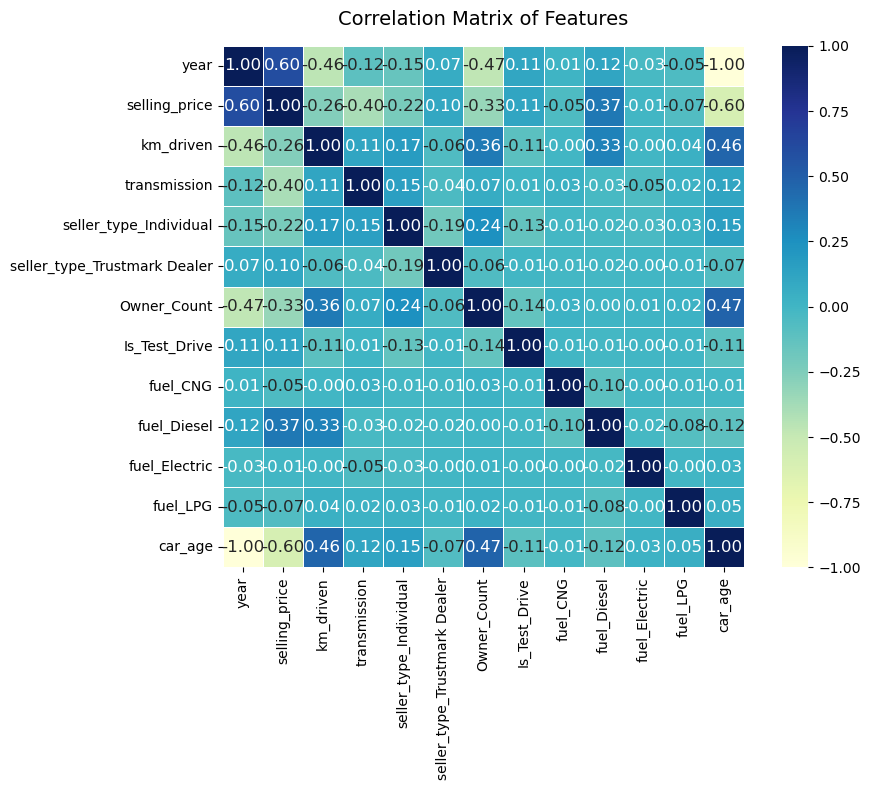

In [56]:
plt.figure(figsize=(10,8))

coorelation= correlation_feature
sns.heatmap(
    coorelation,
    annot=True,
    annot_kws={'size': 12},
    fmt='.2f',            
    cmap='YlGnBu',      
    linewidths=0.5,
    linecolor='white',
    square=True,
    
)
plt.title("Correlation Matrix of Features",fontsize = 14, pad = 15)
plt.tight_layout()
plt.savefig("Correlation Matrix")
plt.show()

**Newer cars** = **Higher price** <br>
**Diesel cars** fetch **more money** <br>
Automatic cars are priced higher<br>

**Older cars** have **more owners**<br>
Older car has driven more kms<br>
Like many more **real thoughts** are present in my **correlation matrix** so that mean matrix is not so bad, I more likely tried to **avoid Multicollinearity** as much i can for Linear reg model.

# Spliting Data

In [38]:
from sklearn.model_selection import train_test_split
features = ['km_driven', 'transmission',
       'seller_type_Individual', 'seller_type_Trustmark Dealer', 'Owner_Count',
       'Is_Test_Drive', 'fuel_CNG', 'fuel_Diesel', 'fuel_Electric', 'fuel_LPG',
       'car_brand_Audi', 'car_brand_BMW', 'car_brand_Chevrolet',
       'car_brand_Daewoo', 'car_brand_Datsun', 'car_brand_Fiat',
       'car_brand_Force', 'car_brand_Ford', 'car_brand_Honda',
       'car_brand_Hyundai', 'car_brand_Isuzu', 'car_brand_Jaguar',
       'car_brand_Jeep', 'car_brand_Kia', 'car_brand_Land', 'car_brand_MG',
       'car_brand_Mahindra', 'car_brand_Maruti', 'car_brand_Mercedes-Benz',
       'car_brand_Mitsubishi', 'car_brand_Nissan', 'car_brand_OpelCorsa',
       'car_brand_Renault', 'car_brand_Skoda', 'car_brand_Tata',
       'car_brand_Toyota', 'car_brand_Volkswagen', 'car_brand_Volvo',
       'car_age']
X = data[features]
y = np.log1p(data['selling_price'])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state = 42)

# Base Model Model 1

In [41]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, root_mean_squared_error, r2_score

model_base = LinearRegression()
model_base.fit(X_train, y_train)

y_pred_base = model_base.predict(X_test)

# Accurcy test
MAE_base = mean_absolute_error(y_test,y_pred_base)
MSE_base = mean_squared_error(y_test,y_pred_base)
RMSE_base = root_mean_squared_error(y_test,y_pred_base)
R2_base = r2_score(y_test, y_pred_base)
print(f"MAE of Linear Regression Model-> {MAE_base}\nMsE of Linear Regression Model-> {MSE_base}\nRMSE of Linear Regression Model-> {RMSE_base}\nR2 of Linear Regression Model-->  {R2_base}")


MAE of Linear Regression Model-> 0.30258281527503583
MsE of Linear Regression Model-> 0.15007458694192444
RMSE of Linear Regression Model-> 0.3873946139815633
R2 of Linear Regression Model-->  0.7532618676264692


# Model 2

In [42]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, root_mean_squared_error, r2_score

model_rf = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=15, min_samples_leaf= 2)
model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_test)       

MAE_rf  = mean_absolute_error(y_test,y_pred_rf)       
MSE_rf  = mean_squared_error(y_test,y_pred_rf)        
RMSE_rf = root_mean_squared_error(y_test, y_pred_rf)   #
R2_rf   = r2_score(y_test, y_pred_rf)                  

print(f"{MAE_rf}\n{MSE_rf}\n{RMSE_rf}\n{R2_rf}")

0.28479648794774365
0.14256934240766536
0.37758355685551953
0.7656012653694484


# Model 3

In [43]:
from xgboost import XGBRegressor

model_xgb = XGBRegressor(n_estimators=100, random_state=42)
model_xgb.fit(X_train, y_train)

y_pred_xgb = model_xgb.predict(X_test)

print("MAE  :", mean_absolute_error(y_test, y_pred_xgb))
print("MSE :", mean_squared_error(y_test, y_pred_xgb))
print("RMSE:", root_mean_squared_error(y_test, y_pred_xgb))
print("R2  :", r2_score(y_test,y_pred_xgb))

MAE  : 0.28752154458703627
MSE : 0.13881060600452683
RMSE: 0.3725729539359061
R2  : 0.7717810165124831


In [ ]:
# Check training score vs test score
train_r2 = r2_score(y_train, model_rf.predict(X_train))
test_r2  = r2_score(y_test,  model_rf.predict(X_test))

print(f"Train R²: {train_r2:.4f}")+
print(f"Test  R²: {test_r2:.4f}")
print(f"Gap     : {train_r2 - test_r2:.4f}")

# Model Comparison Matrix + Visuals

In [45]:
# Comparision Matrix
comparison = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Random Forest',
        'XGBoost'
    ],
    'MAE': [
        MAE_base,
        MAE_rf,
        mean_absolute_error(y_test, y_pred_xgb)
    ],
    'MSE': [
        MSE_base,
        MSE_rf,
        mean_squared_error(y_test, y_pred_xgb)
    ],
    'RMSE': [
        RMSE_base,
        RMSE_rf,
        root_mean_squared_error(y_test, y_pred_xgb)
    ],
    'R²': [
        R2_base,
        R2_rf,
        r2_score(y_test, y_pred_xgb)
    ]
})

comparison

,Model,MAE,MSE,RMSE,R²
0,Linear Regression,0.302583,0.150075,0.387395,0.753262
1,Random Forest,0.284796,0.142569,0.377584,0.765601
2,XGBoost,0.287522,0.138811,0.372573,0.771781


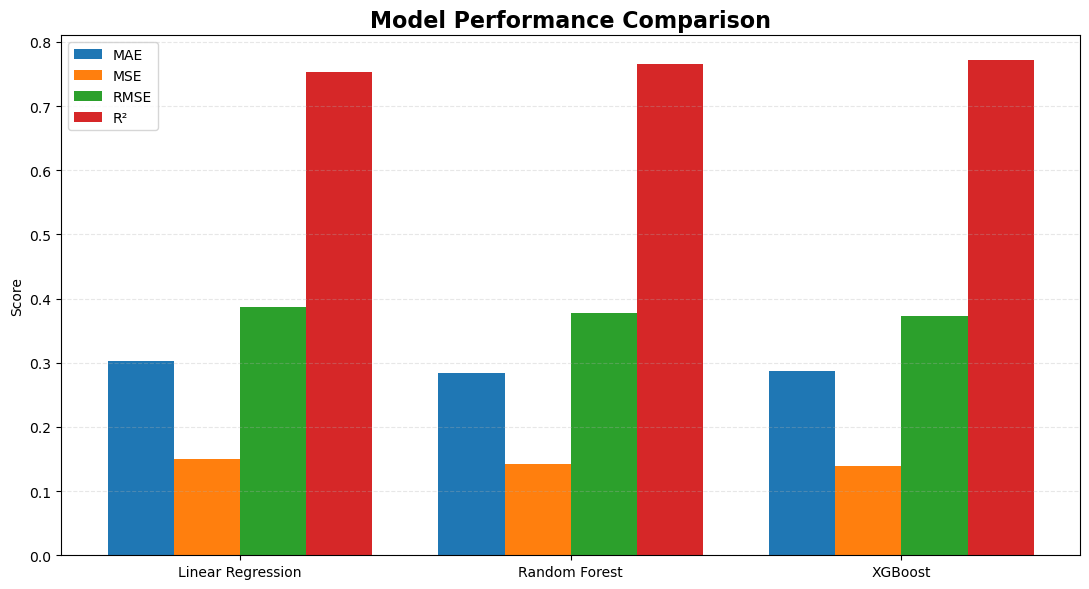

In [55]:
# Visuals
fig, ax = plt.subplots(figsize=(11, 6))

x = range(len(comparison['Model']))
width = 0.2

ax.bar(
    [i - 1.5 * width for i in x],
    comparison['MAE'],
    width,
    label='MAE'
)

ax.bar(
    [i - 0.5 * width for i in x],
    comparison['MSE'],
    width,
    label='MSE'
)

ax.bar(
    [i + 0.5 * width for i in x],
    comparison['RMSE'],
    width,
    label='RMSE'
)

ax.bar(
    [i + 1.5 * width for i in x],
    comparison['R²'],
    width,
    label='R²'
)

ax.set_xticks(x)
ax.set_xticklabels(comparison['Model'])

ax.set_ylabel('Score')
ax.set_title(
    'Model Performance Comparison',
    fontsize=16,
    fontweight='bold'
)

ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig("Model performance Comparision.png")
plt.show()

**XGBoost** achieved the best overall predictive performance with an **R²** score of **0.7772** and the lowest MSE (0.1382) and RMSE (0.3715). Random Forest achieved the lowest MAE (0.2848), while Linear Regression performed the weakest overall. Therefore, XGBoost was selected as the final model based on its superior overall predictive performance.

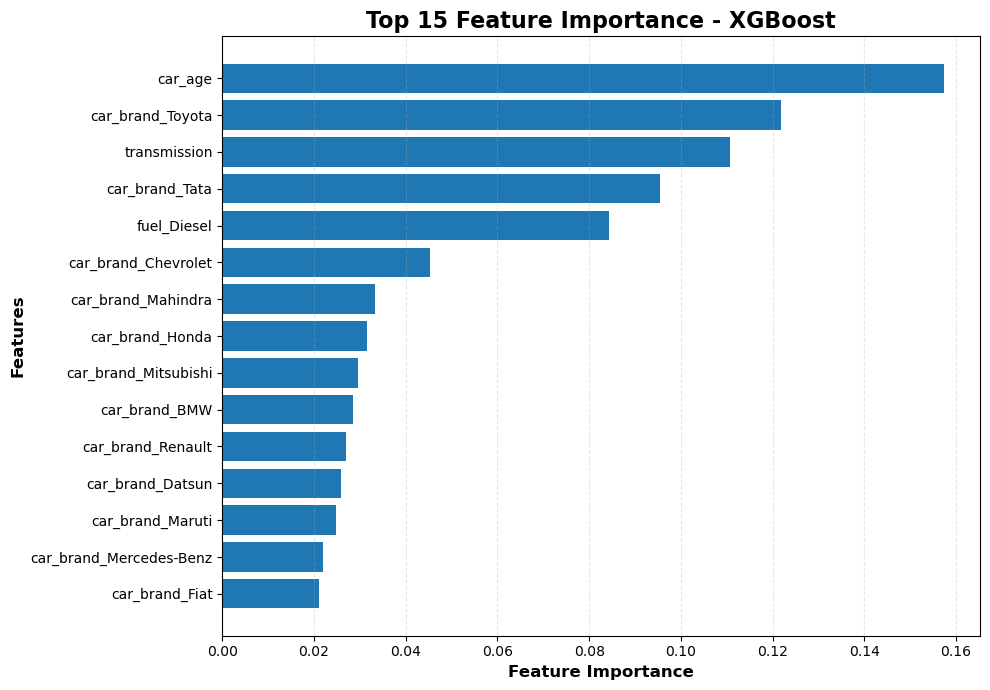

In [50]:
n_features = 15

# Get feature importance
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': model_xgb.feature_importances_
})

# Sort and select top 15
feature_importance = (
    feature_importance
    .sort_values(by='Importance', ascending=False)
    .head(n_features)
    .sort_values(by='Importance', ascending=True)
)

# Plot
plt.figure(figsize=(10, 7))

plt.barh(
    feature_importance['Feature'],
    feature_importance['Importance']
)

plt.xlabel('Feature Importance', fontsize=12, fontweight='bold')
plt.ylabel('Features', fontsize=12, fontweight='bold')

plt.title(
    'Top 15 Feature Importance - XGBoost',
    fontsize=16,
    fontweight='bold'
)

plt.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

1. Vehicle Age (15.7%): The single most dominant factor. Depreciation is the hardest-hitting metric on value.
2. Brand Reliability - Toyota (12%): The market clearly prices in a "reliability premium" for Toyota vehicles over other brands.
3. Transmission (11%): Automatic transmissions hold significantly more value in the second-hand market.
Conclusion: For a dealership or seller, sourcing newer, automatic Toyotas will yield the highest consistent resale margins.